# Task 3: Optimization of Models Operating on Sequential Data

- **Author:** Patryk Chamera  
- **Email:** pchamera@student.agh.edu.pl  
- **Student Index:** 420201

## Project Description

The goal is to build and optimize multi-label neural classifiers for toxic comment detection, beginning with classical sequential models (**RNN, LSTM, GRU**) and then transitioning to a Transformer-based approach (**BERT**). The project emphasizes both model quality and optimization methodology, including hyperparameter tuning, regularization strategies, and metric-driven comparison.

## Dataset Information

- **Dataset:** Jigsaw Toxic Comment Classification Challenge  
- **Source:** https://www.kaggle.com/competitions/jigsaw-toxic-comment-classification-challenge/data

### Data Files

The dataset is stored in the local `data/` directory and includes:

- `train.csv` - training comments with six binary toxicity labels.
- `test.csv` - test comments without final competition labels.
- `test_labels.csv` - labels for a subset of test rows (used in the original challenge setup).
- `sample_submission.csv` - template for Kaggle submission format.

### Multi-Label Target Representation

Each comment can belong to **zero, one, or multiple** classes simultaneously. Target columns are:

- `toxic`
- `severe_toxic`
- `obscene`
- `threat`
- `insult`
- `identity_hate`

All targets are represented as binary indicators (`0` or `1`) in tabular CSV format, where each row corresponds to one text comment and its label vector.

---

## Notebook Roadmap

1. Data loading and initial inspection.
2. Exploratory data analysis and cleaning decisions.
3. Text preprocessing and tokenization pipelines.
4. Baseline sequential models: RNN, LSTM, GRU.
5. Transformer model: BERT fine-tuning.
6. Optimization experiments (hyperparameters, regularization, thresholds).
7. Final evaluation and model comparison using multi-label metrics.


## Part 1: Data Exploration (EDA) and Cleaning

This section loads all competition files, validates schema and types, characterizes **multi-label** toxicity patterns, inspects comment text at the surface level, and defines a **conservative** cleaning pipeline suitable for both classical token-ID models and **BERT** (minimal distortion of surface form).

### 1.1 Data Loading and Schema Validation

We load `train.csv`, `test.csv`, `test_labels.csv`, and `sample_submission.csv`. Training data provides `comment_text` and six binary labels. Public test labels use `-1` for withheld rows (Kaggle design); we report schema for all files and use only **known** test labels where applicable.

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import re

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

from IPython.display import display

# Project root: run the notebook from the repository root (folder that contains `data/`)
NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR / "data"

LABEL_COLS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

# Shared text-noise patterns (used in §1.3 diagnostics and §1.4 cleaning)
URL_RE = re.compile(r"(https?://\S+|www\.\S+)", re.IGNORECASE)
MENTION_RE = re.compile(r"(?:^|\s)@\w{2,}|(?:^|\s)User:\s*\S+", re.IGNORECASE)
REPEAT_PUNCT_RE = re.compile(r"([!?.,\-])\1{2,}")

train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"
test_labels_path = DATA_DIR / "test_labels.csv"
sample_sub_path = DATA_DIR / "sample_submission.csv"

for p in (train_path, test_path, test_labels_path, sample_sub_path):
    if not p.exists():
        raise FileNotFoundError(f"Expected file not found: {p.resolve()}")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
test_labels_df = pd.read_csv(test_labels_path)
sample_sub_df = pd.read_csv(sample_sub_path)

# --- Schema validation ---
expected_train = set(["id", "comment_text", *LABEL_COLS])
if set(train_df.columns) != expected_train:
    missing = expected_train - set(train_df.columns)
    extra = set(train_df.columns) - expected_train
    raise ValueError(f"train.csv column mismatch. Missing: {missing}, Extra: {extra}")

expected_test = {"id", "comment_text"}
if set(test_df.columns) != expected_test:
    raise ValueError(f"test.csv must have columns {expected_test}, got {set(test_df.columns)}")

expected_tl = set(["id", *LABEL_COLS])
if set(test_labels_df.columns) != expected_tl:
    raise ValueError(f"test_labels.csv column mismatch: {set(test_labels_df.columns)}")

expected_sub = set(["id", *LABEL_COLS])
if set(sample_sub_df.columns) != expected_sub:
    raise ValueError(f"sample_submission.csv column mismatch: {set(sample_sub_df.columns)}")

# Enforce label dtypes on train
for c in LABEL_COLS:
    train_df[c] = pd.to_numeric(train_df[c], errors="coerce").fillna(0).astype(np.int8)
    if not set(train_df[c].unique()).issubset({0, 1}):
        raise ValueError(f"train column {c} must be 0/1 only")

# test_labels may contain -1 (withheld)
for c in LABEL_COLS:
    test_labels_df[c] = pd.to_numeric(test_labels_df[c], errors="coerce")

print("Paths OK:", DATA_DIR.resolve())
print("\n--- Row counts ---")
print(f"train:           {len(train_df):,}")
print(f"test:            {len(test_df):,}")
print(f"test_labels:     {len(test_labels_df):,}")
print(f"sample_sub:      {len(sample_sub_df):,}")

print("\n--- train dtypes ---")
print(train_df.dtypes)

print("\n--- test_labels value checks (per column) ---")
for c in LABEL_COLS:
    u = sorted(test_labels_df[c].dropna().unique().tolist())
    print(f"  {c}: unique values (sample) {u[:10]}{'...' if len(u) > 10 else ''}")

# Missing values
print("\n--- Missing values (train) ---")
print(train_df.isna().sum())
print("\n--- Missing values (test comment_text) ---")
print(test_df.isna().sum())

# Merge test with labels for rows where all labels are known (no -1)
test_merged = test_df.merge(test_labels_df, on="id", how="left")
mask_known = (test_merged[LABEL_COLS] != -1).all(axis=1)
test_labeled = test_merged.loc[mask_known].copy()
for c in LABEL_COLS:
    test_labeled[c] = test_labeled[c].astype(np.int8)

n_withheld = (~mask_known).sum()
print(f"\nTest rows with fully known labels: {len(test_labeled):,} / {len(test_merged):,}")
print(f"Test rows with any withheld label (-1): {n_withheld:,}")

display(train_df.head(2))
display(test_df.head(2))

Paths OK: C:\Users\chame\studia\sem6\Glebokie-i-grafowe-sieci-neuronowe\toxic-comment-classification\data

--- Row counts ---
train:           159,571
test:            153,164
test_labels:     153,164
sample_sub:      153,164

--- train dtypes ---
id               object
comment_text     object
toxic              int8
severe_toxic       int8
obscene            int8
threat             int8
insult             int8
identity_hate      int8
dtype: object

--- test_labels value checks (per column) ---
  toxic: unique values (sample) [-1, 0, 1]
  severe_toxic: unique values (sample) [-1, 0, 1]
  obscene: unique values (sample) [-1, 0, 1]
  threat: unique values (sample) [-1, 0, 1]
  insult: unique values (sample) [-1, 0, 1]
  identity_hate: unique values (sample) [-1, 0, 1]

--- Missing values (train) ---
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

--- Missing values (test

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0


,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...


### 1.2 Label Distribution and Multi-Label Characteristics

We quantify **per-label prevalence**, **class imbalance**, **co-occurrence** of toxicity types, and the share of **clean**, **single-label**, and **multi-label** toxic comments. All statistics below use the **training set**; the partially labeled public test slice (`test_labeled`) is summarized for context.

In [2]:
def label_summary(df: pd.DataFrame, name: str) -> None:
    y = df[LABEL_COLS].to_numpy(dtype=np.int64)
    n = len(df)
    pos = y.sum(axis=0)
    prev = pos / max(n, 1)
    # Imbalance ratio: negatives per positive (common in toxic comment literature)
    neg = n - pos
    imb = np.where(pos > 0, neg / pos, np.inf)

    print(f"\n========== {name} (n={n:,}) ==========")
    prev_tbl = pd.DataFrame(
        {"label": LABEL_COLS, "positives": pos.astype(int), "prevalence": prev, "neg_per_pos": imb}
    )
    display(prev_tbl)

    label_sum = y.sum(axis=1)
    n_clean = int((label_sum == 0).sum())
    n_single = int((label_sum == 1).sum())
    n_multi = int((label_sum >= 2).sum())
    n_any = int((label_sum >= 1).sum())

    print(
        f"Clean (all zeros):     {n_clean:,}  ({100 * n_clean / n:.2f}%)\n"
        f"Any toxic (≥1):      {n_any:,}  ({100 * n_any / n:.2f}%)\n"
        f"Single-label toxic:  {n_single:,}  ({100 * n_single / n:.2f}%)\n"
        f"Multi-label toxic:   {n_multi:,}  ({100 * n_multi / n:.2f}%)"
    )

    # Co-occurrence among positive pairs (symmetric counts)
    co = np.zeros((len(LABEL_COLS), len(LABEL_COLS)), dtype=np.int64)
    for row in y:
        idx = np.where(row == 1)[0]
        for i in idx:
            co[i, idx] += 1
    co_df = pd.DataFrame(co, index=LABEL_COLS, columns=LABEL_COLS)
    print("\nCo-occurrence matrix (counts of rows where both labels are 1):")
    display(co_df)

    # Frequent label combinations (only toxic rows)
    toxic_rows = df.loc[label_sum >= 1].copy()
    def combo_str(r):
        active = [LABEL_COLS[i] for i, v in enumerate(r[LABEL_COLS].tolist()) if int(v) == 1]
        return "+".join(active)

    toxic_rows["_combo"] = toxic_rows.apply(combo_str, axis=1)
    print("\nTop 15 label combinations (among toxic comments):")
    display(toxic_rows["_combo"].value_counts().head(15))


label_summary(train_df, "TRAIN")
if len(test_labeled) > 0:
    label_summary(test_labeled, "TEST (known labels only)")
else:
    print("No fully labeled test rows; skip test label summary.")


========== TRAIN (n=159,571) ==========


,label,positives,prevalence,neg_per_pos
0,toxic,15294,0.095844,9.433569
1,severe_toxic,1595,0.009996,99.044514
2,obscene,8449,0.052948,17.886377
3,threat,478,0.002996,332.830544
4,insult,7877,0.049364,19.257839
5,identity_hate,1405,0.008805,112.573665


Clean (all zeros):     143,346  (89.83%)
Any toxic (≥1):      16,225  (10.17%)
Single-label toxic:  6,360  (3.99%)
Multi-label toxic:   9,865  (6.18%)

Co-occurrence matrix (counts of rows where both labels are 1):


,toxic,severe_toxic,obscene,threat,insult,identity_hate
toxic,15294,1595,7926,449,7344,1302
severe_toxic,1595,1595,1517,112,1371,313
obscene,7926,1517,8449,301,6155,1032
threat,449,112,301,478,307,98
insult,7344,1371,6155,307,7877,1160
identity_hate,1302,313,1032,98,1160,1405



Top 15 label combinations (among toxic comments):


...

,label,positives,prevalence,neg_per_pos
0,toxic,6090,0.095189,9.505419
1,severe_toxic,367,0.005736,173.326975
2,obscene,3691,0.057692,16.333514
3,threat,211,0.003298,302.213270
4,insult,3427,0.053565,17.668807
5,identity_hate,712,0.011129,88.856742


Clean (all zeros):     57,735  (90.24%)
Any toxic (≥1):      6,243  (9.76%)
Single-label toxic:  1,842  (2.88%)
Multi-label toxic:   4,401  (6.88%)

Co-occurrence matrix (counts of rows where both labels are 1):


,toxic,severe_toxic,obscene,threat,insult,identity_hate
toxic,6090,367,3626,205,3342,693
severe_toxic,367,367,363,46,330,135
obscene,3626,363,3691,138,2729,538
threat,205,46,138,211,138,47
insult,3342,330,2729,138,3427,602
identity_hate,693,135,538,47,602,712



Top 15 label combinations (among toxic comments):


_combo
toxic+obscene+insult                               1932
toxic                                              1710
toxic+obscene                                       854
toxic+insult                                        539
toxic+obscene+insult+identity_hate                  361
toxic+severe_toxic+obscene+insult                   176
toxic+severe_toxic+obscene+insult+identity_hate     116
toxic+insult+identity_hate                           81
toxic+identity_hate                                  67
toxic+obscene+threat+insult                          65
insult                                               64
toxic+threat                                         50
obscene                                              49
toxic+severe_toxic+obscene                           28
toxic+obscene+threat+insult+identity_hate            25
Name: count, dtype: int64

### 1.3 Text-Level Diagnostics

We study **length** distributions: raw **characters**, **whitespace-separated words**, and a third **regex-based token count** (`\w+` runs) as a coarse surface-token proxy. **Subword** lengths for BERT (WordPiece) are reported in the Transformer section. We also flag common **noise** (URLs, handles, repeated punctuation, non-ASCII ratio) and show **representative** training examples per label and for frequent multi-label combinations.

Train — noisy artifact rates (fraction of comments with ≥1 hit)


,metric,value
0,>=1 URL,0.032048
1,>=1 mention-like,0.013248
2,>=1 repeated punct run,0.096452
3,median non-ASCII ratio,0.000000


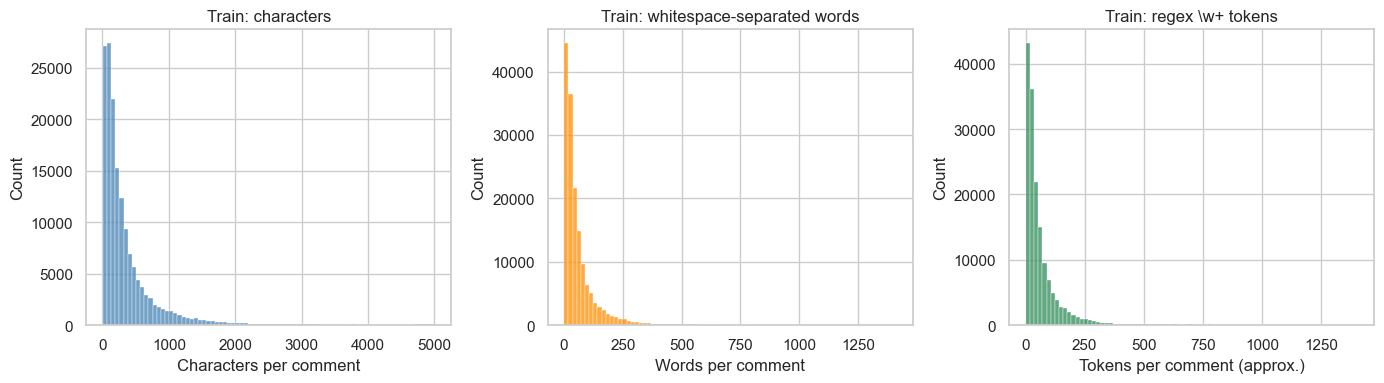

,quantile,char_len,word_len,token_len
0,50%,205.0,36.0,37.0
1,90%,889.0,152.0,156.0
2,95%,1355.0,230.0,235.0
3,99%,3444.0,567.0,587.0



Representative examples — one label active (others 0 where possible)

--- toxic (show up to 2) ---
  [1] Hey... what is it.. @ | talk . What is it... an exclusive group of some WP TALIBANS...who are good at destroying, self-appointed purist who GANG UP any one who asks them questions abt their ANTI-SOCIAL and DESTRUCTIVE (non)-contribution at WP? Ask Sityush to clean up his behavior than issue me nonsensical warnings...

  [2] Bye! Don't look, come or think of comming back! Tosser.


--- severe_toxic (show up to 2) ---
  [1] COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK

  [2] Stupid peace of shit stop deleting my stuff asshole go die and fall in a hole go to hell!


--- obscene (show up to 2) ---
  [1] How do you know he is dead. Its just his plane that crashed. Jeezz, quit busting his nuts, folks.

  [2] Bleh. I'm all out of ideas. Is there really something wrong with the server or what? The damn thing won't work for me, either Helvetica_font_new.svg (my upload of Segoe UI was actual

In [3]:
import re

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")


def text_features(s: pd.Series) -> pd.DataFrame:
    s = s.fillna("").astype(str)
    char_len = s.str.len()
    word_len = s.str.split().str.len()
    # Alphanumeric tokens (rough surface token count; BERT WordPiece counts are added in the Transformer section)
    token_len = s.apply(lambda t: len(re.findall(r"\w+", t, flags=re.UNICODE)))
    out = pd.DataFrame({"char_len": char_len, "word_len": word_len, "token_len": token_len})
    out["url_count"] = s.apply(lambda t: len(URL_RE.findall(t)))
    out["mention_count"] = s.apply(lambda t: len(MENTION_RE.findall(t)))
    out["repeat_punct_hits"] = s.apply(lambda t: len(REPEAT_PUNCT_RE.findall(t)))
    out["non_ascii_ratio"] = s.apply(
        lambda t: (sum(1 for ch in t if ord(ch) > 127) / max(len(t), 1))
    )
    return out


def plot_length_diagnostics(features: pd.DataFrame, title: str) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    sns.histplot(features["char_len"], bins=80, kde=False, ax=axes[0], color="steelblue")
    axes[0].set_title(f"{title}: characters")
    axes[0].set_xlabel("Characters per comment")
    sns.histplot(features["word_len"], bins=80, kde=False, ax=axes[1], color="darkorange")
    axes[1].set_title(f"{title}: whitespace-separated words")
    axes[1].set_xlabel("Words per comment")
    sns.histplot(features["token_len"], bins=80, kde=False, ax=axes[2], color="seagreen")
    axes[2].set_title(f"{title}: regex \\w+ tokens")
    axes[2].set_xlabel("Tokens per comment (approx.)")
    plt.tight_layout()
    plt.show()

    qs = [0.5, 0.9, 0.95, 0.99]
    qdf = pd.DataFrame(
        {
            "quantile": [f"{int(q * 100)}%" for q in qs],
            "char_len": features["char_len"].quantile(qs).values,
            "word_len": features["word_len"].quantile(qs).values,
            "token_len": features["token_len"].quantile(qs).values,
        }
    )
    display(qdf)


train_txt = train_df["comment_text"]
feat_train = text_features(train_txt)
print("Train — noisy artifact rates (fraction of comments with ≥1 hit)")
display(
    pd.DataFrame(
        {
            "metric": [">=1 URL", ">=1 mention-like", ">=1 repeated punct run", "median non-ASCII ratio"],
            "value": [
                (feat_train["url_count"] > 0).mean(),
                (feat_train["mention_count"] > 0).mean(),
                (feat_train["repeat_punct_hits"] > 0).mean(),
                feat_train["non_ascii_ratio"].median(),
            ],
        }
    )
)

plot_length_diagnostics(feat_train, "Train")


def show_examples(mask: pd.Series, k: int = 2, max_chars: int = 320) -> None:
    sub = train_df.loc[mask, "comment_text"].dropna().head(k)
    for i, t in enumerate(sub.tolist(), 1):
        t_one = " ".join(str(t).split())
        if len(t_one) > max_chars:
            t_one = t_one[: max_chars - 3] + "..."
        print(f"  [{i}] {t_one}\n")


print("\nRepresentative examples — one label active (others 0 where possible)")
for lab in LABEL_COLS:
    pure = train_df[lab] == 1
    others = (train_df[[c for c in LABEL_COLS if c != lab]].sum(axis=1) == 0)
    m = pure & others
    if m.sum() == 0:
        m = train_df[lab] == 1
    print(f"\n--- {lab} (show up to 2) ---")
    show_examples(m, k=2)

print("\nRepresentative examples — top multi-label combos (train)")
top_combos = (
    train_df.assign(
        _k=train_df[LABEL_COLS].sum(axis=1),
        _combo=train_df.apply(
            lambda r: "+".join([c for c in LABEL_COLS if int(r[c]) == 1]), axis=1,
        ),
    )
    .query("_k >= 2")["_combo"]
    .value_counts()
    .head(5)
    .index.tolist()
)
for combo in top_combos:
    cols = combo.split("+")
    m = (train_df[cols] == 1).all(axis=1)
    print(f"\n--- {combo} ---")
    show_examples(m, k=2)

### 1.4 Cleaning Strategy

We apply **conservative** normalization that preserves toxic cues (slurs, insult wording) while reducing spurious variation from encoding, layout, and boilerplate links. **BERT** (`bert-base-uncased`) tolerates light normalization; we avoid aggressive stemming or vocabulary stripping. Classical RNN/LSTM/GRU pipelines may additionally use **lowercasing** and the same masking rules for a fair comparison.

| Step | RNN-friendly | BERT-friendly |
|------|----------------|---------------|
| Unicode NFKC | yes | yes |
| Collapse whitespace | yes | yes |
| Lowercase | recommended | optional (uncased model) |
| Mask URLs / `User:`-style mentions | optional | optional (keeps length; removes site noise) |

In [4]:
import unicodedata


def clean_comment_text(
    text: str,
    *,
    unicode_norm: str = "NFKC",
    lowercase: bool = False,
    mask_urls: bool = True,
    mask_user_mentions: bool = True,
    collapse_whitespace: bool = True,
) -> str:
    """Conservative cleaning for toxicity classification.

    Does not remove punctuation or stopwords. Optional masking replaces URLs and
    `User:`-style wiki handles with fixed tokens to limit out-of-vocabulary noise.
    """
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return ""
    t = str(text)
    if unicode_norm:
        t = unicodedata.normalize(unicode_norm, t)
    if lowercase:
        t = t.lower()
    if mask_urls:
        t = URL_RE.sub(" <URL> ", t)
    if mask_user_mentions:
        t = MENTION_RE.sub(" <USER> ", t)
    if collapse_whitespace:
        t = " ".join(t.split())
    return t.strip()


# Two presets used later in the notebook
def clean_for_bert(text: str) -> str:
    return clean_comment_text(text, lowercase=False, mask_urls=True, mask_user_mentions=True)


def clean_for_baseline_tokenizer(text: str) -> str:
    """Embedding + RNN family: uncased vocabulary is standard with bert-base-uncased comparisons."""
    return clean_comment_text(text, lowercase=True, mask_urls=True, mask_user_mentions=True)


rng = np.random.default_rng(42)
sample_idx = rng.choice(len(train_df), size=min(5, len(train_df)), replace=False)
sample = train_df.iloc[sample_idx][["id", "comment_text"]].copy()
sample["clean_bert"] = sample["comment_text"].map(clean_for_bert)
sample["clean_rnn"] = sample["comment_text"].map(clean_for_baseline_tokenizer)
print("Random sample: raw vs cleaned")
display(sample)


Random sample: raw vs cleaned


,id,comment_text,clean_bert,clean_rnn
123498,949ba471139ce699,I'll try to take a look tomorrow. There is a ...,I'll try to take a look tomorrow. There is a n...,i'll try to take a look tomorrow. there is a n...
70031,bb5cdc9f21794814,WORST MOVIE EVER \n\nFROZEN SUCKS\nFROZEN SUCK...,WORST MOVIE EVER FROZEN SUCKS FROZEN SUCKSFROZ...,worst movie ever frozen sucks frozen sucksfroz...
104449,2eca64c38a8dc0d9,Hello CLOWN\nYou have energized me...You peopl...,Hello CLOWN You have energized me...You people...,hello clown you have energized me...you people...
14241,259837ca06443a5b,The links now seem to work on another computer...,The links now seem to work on another computer...,the links now seem to work on another computer...
69096,b8da22c2e1522056,How about you go fuck yourself you cunt...,How about you go fuck yourself you cunt...,how about you go fuck yourself you cunt...


## Part 2: Text Preprocessing and Tokenization

This section prepares reproducible experimental inputs for both model families used in Task 3:

- **Sequential models** (RNN / LSTM / GRU): integer token IDs with fixed-length padding.
- **Transformer models** (BERT): subword tokenization with attention masks and optional dynamic padding.

The pipeline is designed for multi-label classification and integrates reproducible split logic, reusable helpers, and metrics compatible with thresholded sigmoid outputs.

### 2.1 Common Experimental Setup

Goals:

1. Build a reproducible train/validation split with **iterative multilabel stratification** when available.
2. Fix seeds and deterministic behavior where possible.
3. Provide reusable helpers for preprocessing, mini-batching, and multi-label metrics (ROC-AUC, F1, precision, recall).


In [5]:
import os
import random
from dataclasses import dataclass
from typing import Dict, Iterable, Tuple

import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split


# -------------------------------
# Reproducibility
# -------------------------------
SEED = 42
VAL_SIZE = 0.2


def seed_everything(seed: int = 42) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch

        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except Exception:
        pass


seed_everything(SEED)


# -------------------------------
# Reusable text accessors
# -------------------------------
if "clean_for_baseline_tokenizer" not in globals():
    def clean_for_baseline_tokenizer(text: str) -> str:
        return "" if pd.isna(text) else " ".join(str(text).lower().split())

if "clean_for_bert" not in globals():
    def clean_for_bert(text: str) -> str:
        return "" if pd.isna(text) else " ".join(str(text).split())


# -------------------------------
# Iterative split if available
# -------------------------------
def multilabel_train_val_split(
    df: pd.DataFrame,
    label_cols: Iterable[str],
    text_col: str = "comment_text",
    val_size: float = 0.2,
    seed: int = 42,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    label_cols = list(label_cols)
    y = df[label_cols].values

    try:
        # pip install iterative-stratification
        from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

        msss = MultilabelStratifiedShuffleSplit(
            n_splits=1, test_size=val_size, random_state=seed
        )
        train_idx, val_idx = next(msss.split(df[text_col].values, y))
        split_mode = "iterative_multilabel_stratification"
    except Exception:
        any_toxic = (y.sum(axis=1) > 0).astype(int)
        train_idx, val_idx = train_test_split(
            np.arange(len(df)),
            test_size=val_size,
            random_state=seed,
            stratify=any_toxic,
        )
        split_mode = "fallback_stratify_any_toxic"

    train_split = df.iloc[train_idx].reset_index(drop=True)
    val_split = df.iloc[val_idx].reset_index(drop=True)
    print(f"Split mode: {split_mode}")
    print(f"Train size: {len(train_split):,} | Val size: {len(val_split):,}")
    return train_split, val_split


train_split_df, val_split_df = multilabel_train_val_split(
    train_df, LABEL_COLS, text_col="comment_text", val_size=VAL_SIZE, seed=SEED
)


# -------------------------------
# Multi-label metric helpers
# -------------------------------
@dataclass
class MetricsConfig:
    threshold: float = 0.5


def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))


def evaluate_multilabel(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    threshold: float = 0.5,
) -> Dict[str, float]:
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_micro": precision_score(
            y_true, y_pred, average="micro", zero_division=0
        ),
        "recall_micro": recall_score(y_true, y_pred, average="micro", zero_division=0),
    }

    try:
        metrics["roc_auc_macro"] = roc_auc_score(y_true, y_prob, average="macro")
    except ValueError:
        metrics["roc_auc_macro"] = np.nan

    return metrics


def print_label_prevalence(df: pd.DataFrame, split_name: str) -> None:
    prev = df[LABEL_COLS].mean().rename("prevalence").to_frame()
    prev["positive_count"] = df[LABEL_COLS].sum().astype(int)
    print(f"\n{split_name} label prevalence")
    display(prev)


print_label_prevalence(train_split_df, "Train split")
print_label_prevalence(val_split_df, "Validation split")

Split mode: iterative_multilabel_stratification
Train size: 127,656 | Val size: 31,915

Train split label prevalence


,prevalence,positive_count
toxic,0.095844,12235
severe_toxic,0.009996,1276
obscene,0.052947,6759
threat,0.002992,382
insult,0.049367,6302
identity_hate,0.008805,1124



Validation split label prevalence


,prevalence,positive_count
toxic,0.095848,3059
severe_toxic,0.009995,319
obscene,0.052953,1690
threat,0.003008,96
insult,0.049350,1575
identity_hate,0.008805,281


### 2.2 Sequential Models (RNN/LSTM/GRU) Pipeline

This pipeline prepares fixed-length integer sequences suitable for `Embedding + RNN/GRU/LSTM` architectures.

- Tokenizer: Keras-style tokenizer with configurable `num_words` and optional `oov_token`.
- Sequence shaping: deterministic pad/truncate strategy.
- Embeddings: baseline assumes trainable random initialization in the model `Embedding` layer.
- Optional extension function is included for loading pretrained vectors (e.g., GloVe) later.

In [6]:
# Tokenization utilities for sequential models.
# Priority:
# 1) TensorFlow Keras utilities (if TensorFlow exists)
# 2) Pure-Python fallback (NumPy 2.x compatible; avoids keras_preprocessing issues)
import re
from collections import Counter

try:
    from tensorflow.keras.preprocessing.sequence import pad_sequences as _tf_pad_sequences
    from tensorflow.keras.preprocessing.text import Tokenizer as _TFTokenizer

    Tokenizer = _TFTokenizer
    pad_sequences = _tf_pad_sequences
    _SEQ_BACKEND = "tensorflow.keras"
except Exception:
    _SEQ_BACKEND = "pure_python_fallback"

    class Tokenizer:
        def __init__(self, num_words: int | None = None, oov_token: str | None = None):
            self.num_words = num_words
            self.oov_token = oov_token
            self.word_index: Dict[str, int] = {}

        @staticmethod
        def _tokenize(text: str) -> list[str]:
            # Basic word tokenization compatible with cleaned text
            return re.findall(r"\w+|[^\w\s]", text.lower(), flags=re.UNICODE)

        def fit_on_texts(self, texts):
            counts = Counter()
            for t in texts:
                counts.update(self._tokenize(str(t)))

            self.word_index = {}
            next_idx = 1

            if self.oov_token is not None:
                self.word_index[self.oov_token] = next_idx
                next_idx += 1

            max_vocab = self.num_words - 1 if self.num_words is not None else None
            for word, _ in counts.most_common():
                if word in self.word_index:
                    continue
                if max_vocab is not None and len(self.word_index) >= self.num_words:
                    break
                self.word_index[word] = next_idx
                next_idx += 1

        def texts_to_sequences(self, texts):
            seqs = []
            oov_idx = self.word_index.get(self.oov_token, None)
            for t in texts:
                toks = self._tokenize(str(t))
                ids = []
                for tok in toks:
                    idx = self.word_index.get(tok)
                    if idx is None:
                        if oov_idx is not None:
                            ids.append(oov_idx)
                    else:
                        if self.num_words is None or idx < self.num_words:
                            ids.append(idx)
                        elif oov_idx is not None:
                            ids.append(oov_idx)
                seqs.append(ids)
            return seqs

    def pad_sequences(
        sequences,
        maxlen: int,
        padding: str = "post",
        truncating: str = "post",
        value: int = 0,
        dtype=np.int32,
    ):
        arr = np.full((len(sequences), maxlen), fill_value=value, dtype=dtype)
        for i, seq in enumerate(sequences):
            seq = list(seq)
            if len(seq) > maxlen:
                seq = seq[-maxlen:] if truncating == "pre" else seq[:maxlen]
            if padding == "pre":
                arr[i, -len(seq):] = seq
            else:
                arr[i, :len(seq)] = seq
        return arr


# For faster local CPU runs, lower e.g. num_words=20000, max_len=128, then re-run this cell.
SEQ_CONFIG = {
    "num_words": 50000,
    "max_len": 256,
    "oov_token": "<OOV>",
    "padding": "post",
    "truncating": "post",
}


def prepare_sequential_inputs(
    train_texts: pd.Series,
    val_texts: pd.Series,
    train_labels: np.ndarray,
    val_labels: np.ndarray,
    num_words: int = 50000,
    max_len: int = 256,
    oov_token: str | None = "<OOV>",
    padding: str = "post",
    truncating: str = "post",
):
    tokenizer = Tokenizer(num_words=num_words, oov_token=oov_token)
    tokenizer.fit_on_texts(train_texts.tolist())

    train_seq = tokenizer.texts_to_sequences(train_texts.tolist())
    val_seq = tokenizer.texts_to_sequences(val_texts.tolist())

    X_train = pad_sequences(train_seq, maxlen=max_len, padding=padding, truncating=truncating)
    X_val = pad_sequences(val_seq, maxlen=max_len, padding=padding, truncating=truncating)

    y_train = np.asarray(train_labels, dtype=np.float32)
    y_val = np.asarray(val_labels, dtype=np.float32)

    vocab_size = min(num_words, len(tokenizer.word_index) + 1)

    return {
        "tokenizer": tokenizer,
        "X_train": X_train,
        "X_val": X_val,
        "y_train": y_train,
        "y_val": y_val,
        "vocab_size": vocab_size,
        "max_len": max_len,
    }


def build_random_embedding_spec(vocab_size: int, embedding_dim: int = 128) -> Dict[str, int]:
    """Spec for a trainable random embedding layer in RNN/LSTM/GRU models."""
    return {
        "input_dim": int(vocab_size),
        "output_dim": int(embedding_dim),
        "trainable": True,
    }


def load_glove_matrix(
    glove_path: str,
    word_index: Dict[str, int],
    vocab_size: int,
    embedding_dim: int,
) -> np.ndarray:
    """Optional extension: build embedding matrix from pretrained vectors (e.g., GloVe).

    Words not found in pretrained vocabulary keep random initialization.
    """
    embedding_matrix = np.random.normal(0, 0.05, (vocab_size, embedding_dim)).astype(np.float32)
    found = 0

    with open(glove_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip().split(" ")
            word = parts[0]
            vec = np.asarray(parts[1:], dtype=np.float32)
            if vec.shape[0] != embedding_dim:
                continue
            idx = word_index.get(word)
            if idx is not None and idx < vocab_size:
                embedding_matrix[idx] = vec
                found += 1

    print(f"Loaded pretrained vectors for {found:,} words (vocab cap: {vocab_size:,}).")
    return embedding_matrix


# Prepare texts with the conservative baseline-cleaning profile
train_text_seq = train_split_df["comment_text"].map(clean_for_baseline_tokenizer)
val_text_seq = val_split_df["comment_text"].map(clean_for_baseline_tokenizer)

seq_data = prepare_sequential_inputs(
    train_texts=train_text_seq,
    val_texts=val_text_seq,
    train_labels=train_split_df[LABEL_COLS].values,
    val_labels=val_split_df[LABEL_COLS].values,
    **SEQ_CONFIG,
)

print("Sequential pipeline summary")
print("Tokenizer backend:", _SEQ_BACKEND)
print(f"X_train shape: {seq_data['X_train'].shape}")
print(f"X_val shape:   {seq_data['X_val'].shape}")
print(f"y_train shape: {seq_data['y_train'].shape}")
print(f"Vocab size (capped): {seq_data['vocab_size']:,}")
print("Embedding spec example:", build_random_embedding_spec(seq_data["vocab_size"], embedding_dim=128))

Sequential pipeline summary
Tokenizer backend: pure_python_fallback
X_train shape: (127656, 256)
X_val shape:   (31915, 256)
y_train shape: (127656, 6)
Vocab size (capped): 50,000
Embedding spec example: {'input_dim': 50000, 'output_dim': 128, 'trainable': True}


### 2.3 Transformer (BERT) Pipeline

This pipeline uses Hugging Face tokenization and prepares tensors for BERT fine-tuning in a multi-label setup.

- Tokenizer: `bert-base-uncased`
- Inputs: `input_ids`, `attention_mask`, and `token_type_ids` when available
- Padding:
  - **Fixed** (`padding='max_length'`) for reproducibility/comparability
  - **Dynamic** (batch-time `DataCollatorWithPadding`) for memory efficiency
- Loss: explicit **`BCEWithLogitsLoss`** for 6-label multi-label classification heads

In [7]:
from typing import Any, List

import torch
from torch.nn import BCEWithLogitsLoss
from torch.utils.data import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
)


BERT_MODEL_NAME = "bert-base-uncased"
BERT_MAX_LEN = 192


class ToxicCommentsDataset(Dataset):
    def __init__(self, encodings: Dict[str, Any], labels: np.ndarray):
        self.encodings = encodings
        self.labels = labels.astype(np.float32)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float32)
        return item


class MultiLabelTrainer(Trainer):
    """Trainer with explicit BCEWithLogitsLoss for multi-label targets."""

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = BCEWithLogitsLoss()(logits, labels)
        return (loss, outputs) if return_outputs else loss


def build_bert_tokenizer(model_name: str = BERT_MODEL_NAME):
    return AutoTokenizer.from_pretrained(model_name)


def encode_texts_fixed(
    tokenizer,
    texts: List[str],
    max_length: int = 192,
):
    """Fixed-length encoding: deterministic shape for all batches."""
    return tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_attention_mask=True,
    )


def encode_texts_dynamic(tokenizer, texts: List[str]):
    """Dynamic-length encoding: minimal padding, use with DataCollatorWithPadding."""
    return tokenizer(
        texts,
        padding=False,
        truncation=True,
        return_attention_mask=True,
    )


def build_multilabel_bert_model(
    model_name: str = BERT_MODEL_NAME,
    num_labels: int = 6,
):
    return AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        problem_type="multi_label_classification",
    )


def hf_compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1.0 / (1.0 + np.exp(-logits))
    return evaluate_multilabel(labels, probs, threshold=0.5)


# Build text inputs for BERT with conservative cleaning
train_text_bert = train_split_df["comment_text"].map(clean_for_bert).tolist()
val_text_bert = val_split_df["comment_text"].map(clean_for_bert).tolist()
y_train_bert = train_split_df[LABEL_COLS].values.astype(np.float32)
y_val_bert = val_split_df[LABEL_COLS].values.astype(np.float32)

bert_tokenizer = build_bert_tokenizer(BERT_MODEL_NAME)

# Fixed-length tensors (simple baseline)
train_enc_fixed = encode_texts_fixed(bert_tokenizer, train_text_bert, max_length=BERT_MAX_LEN)
val_enc_fixed = encode_texts_fixed(bert_tokenizer, val_text_bert, max_length=BERT_MAX_LEN)

train_ds_fixed = ToxicCommentsDataset(train_enc_fixed, y_train_bert)
val_ds_fixed = ToxicCommentsDataset(val_enc_fixed, y_val_bert)

# Dynamic-padding setup (memory-friendly): encode without padding, then collate per batch
dynamic_collator = DataCollatorWithPadding(tokenizer=bert_tokenizer, pad_to_multiple_of=8)

print("BERT pipeline summary")
print(f"Model name: {BERT_MODEL_NAME}")
print(f"Train samples: {len(train_ds_fixed):,} | Val samples: {len(val_ds_fixed):,}")
print("Tokenizer returns token_type_ids:", "token_type_ids" in train_enc_fixed)
print("Fixed max length:", BERT_MAX_LEN)
print("Dynamic collator ready:", dynamic_collator is not None)

# Model object (instantiate in training section when needed)
# bert_model = build_multilabel_bert_model(BERT_MODEL_NAME, num_labels=len(LABEL_COLS))

# Trainer class for later use:
# trainer = MultiLabelTrainer(
#     model=bert_model,
#     args=training_args,
#     train_dataset=train_ds_fixed,
#     eval_dataset=val_ds_fixed,
#     tokenizer=bert_tokenizer,
#     data_collator=dynamic_collator,
#     compute_metrics=hf_compute_metrics,
# )

c:\Users\chame\studia\sem6\Glebokie-i-grafowe-sieci-neuronowe\toxic-comment-classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


BERT pipeline summary
Model name: bert-base-uncased
Train samples: 127,656 | Val samples: 31,915
Tokenizer returns token_type_ids: True
Fixed max length: 192
Dynamic collator ready: True


## Part 3: Baseline Model Implementation

This section implements multi-label baselines on the **integer-sequence** inputs from Part 2 (`seq_data`): **SimpleRNN**, **LSTM** (uni + bi under **`PART3_TRAINING_MODE = "quality"`**), and **GRU**. Training uses **PyTorch** with **`BCEWithLogitsLoss`** (logits head, no sigmoid in the final layer). When **TensorFlow** is installed, an optional **Keras** mirror uses **`binary_crossentropy`** with a sigmoid output.

All models share **six independent sigmoid probabilities** after applying `sigmoid` to logits at inference time.

### 3.1 Shared Multi-Label Classification Design

- **Output dimension:** 6 logits (one per label).
- **Probabilities:** `sigmoid(logits)` at evaluation / inference.
- **PyTorch loss:** `BCEWithLogitsLoss` (numerically stable; no sigmoid on the last layer).
- **TensorFlow / Keras loss (optional):** `binary_crossentropy` on a **sigmoid** output layer.

Recurrent layers use **dropout** after embeddings and before the linear head. **Recurrent dropout** is only applied when `num_rnn_layers > 1` (PyTorch API constraint); with a single layer we rely on embedding and pre-head dropout.

**Training presets (next code cell):** `PART3_TRAINING_MODE = "quality"` uses one shared **`BASELINE_CONFIG`** for **§3.2–§3.4** (embed/hidden 128, batch 256, early stopping): **SimpleRNN, GRU, LSTM-uni, and LSTM-bi** are trained under the same hyperparameters so comparisons are fair. Use `"fast"` only for a **short smoke test** (narrower model, 1 epoch, no biLSTM). Optional: shorten `max_len` / `num_words` in §2.2 and rebuild `seq_data` if runs are too slow.

In [8]:
import time
from typing import Any, Dict, Optional

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

NUM_LABELS = len(LABEL_COLS)

# "quality" — shared 128-dim budget + early stopping; includes LSTM-bi (long on CPU; overnight run is fine)
# "fast"    — small model, 1 epoch, skip LSTM-bi
PART3_TRAINING_MODE = "quality"

BASELINE_CONFIG = {
    "embed_dim": 128,
    "hidden_dim": 128,
    "dropout": 0.3,
    "num_rnn_layers": 1,
    "rnn_dropout": 0.0,
    "batch_size": 256,
    "epochs": 4,
    "min_epochs": 2,
    "early_stopping_patience": 1,
    "lr": 8e-4,
    "weight_decay": 1e-5,
}

if PART3_TRAINING_MODE == "fast":
    BASELINE_CONFIG = {
        **BASELINE_CONFIG,
        "epochs": 1,
        "min_epochs": 1,
        "early_stopping_patience": None,
        "batch_size": 512,
        "embed_dim": 64,
        "hidden_dim": 64,
        "dropout": 0.2,
        "lr": 1e-3,
    }
    RUN_LSTM_BIDIRECTIONAL = False
    print(
        'PART3_TRAINING_MODE="fast": 1 epoch, batch 512, hidden/embed 64; §3.3 skips LSTM-bi.'
    )
elif PART3_TRAINING_MODE == "quality":
    RUN_LSTM_BIDIRECTIONAL = True
    print(
        'PART3_TRAINING_MODE="quality": hidden/embed 128, batch 256, '
        "max epochs=%d with early stopping (patience=%s after min_epochs=%d). "
        "§3.3 trains LSTM-uni + LSTM-bi with the same BASELINE_CONFIG."
        % (
            BASELINE_CONFIG["epochs"],
            BASELINE_CONFIG["early_stopping_patience"],
            BASELINE_CONFIG["min_epochs"],
        )
    )
else:
    raise ValueError('PART3_TRAINING_MODE must be "quality" or "fast"')

LOCAL_CPU_FAST = PART3_TRAINING_MODE == "fast"


def _embedding_vocab_size(X_train: np.ndarray, X_val: np.ndarray) -> int:
    return int(max(np.max(X_train), np.max(X_val))) + 1


def _seq_lengths(x: torch.Tensor) -> torch.Tensor:
    return (x != 0).sum(dim=1).clamp(min=1)


class MultiLabelSeqBaseline(nn.Module):
    """Embedding -> RNN/LSTM/GRU -> Dropout -> Linear(num_labels). Returns logits."""

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_dim: int,
        num_labels: int,
        rnn_type: str,
        bidirectional: bool = False,
        dropout: float = 0.3,
        padding_idx: int = 0,
        num_rnn_layers: int = 1,
        rnn_dropout: float = 0.0,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        self.dropout_emb = nn.Dropout(dropout)
        self.rnn_type = rnn_type.lower()
        self.bidirectional = bidirectional
        nd = 2 if bidirectional else 1
        rnn_dropout = rnn_dropout if num_rnn_layers > 1 else 0.0

        if self.rnn_type == "rnn":
            self.rnn = nn.RNN(
                embed_dim,
                hidden_dim,
                num_layers=num_rnn_layers,
                batch_first=True,
                bidirectional=bidirectional,
                nonlinearity="tanh",
                dropout=rnn_dropout,
            )
        elif self.rnn_type == "lstm":
            self.rnn = nn.LSTM(
                embed_dim,
                hidden_dim,
                num_layers=num_rnn_layers,
                batch_first=True,
                bidirectional=bidirectional,
                dropout=rnn_dropout,
            )
        elif self.rnn_type == "gru":
            self.rnn = nn.GRU(
                embed_dim,
                hidden_dim,
                num_layers=num_rnn_layers,
                batch_first=True,
                bidirectional=bidirectional,
                dropout=rnn_dropout,
            )
        else:
            raise ValueError(f"Unknown rnn_type={rnn_type}")

        self.dropout_out = nn.Dropout(dropout)
        out_dim = hidden_dim * nd
        self.fc = nn.Linear(out_dim, num_labels)

    def forward(self, x: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        emb = self.dropout_emb(self.embedding(x))
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        if self.rnn_type == "lstm":
            _, (h_n, _) = self.rnn(packed)
        else:
            _, h_n = self.rnn(packed)

        if self.bidirectional:
            h = torch.cat([h_n[-2], h_n[-1]], dim=1)
        else:
            h = h_n[-1]

        return self.fc(self.dropout_out(h))


def train_pytorch_baseline(
    model: nn.Module,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    *,
    config: Dict[str, Any],
    device: torch.device,
    model_name: str = "model",
) -> Dict[str, Any]:
    cfg = {**BASELINE_CONFIG, **config}
    bs = int(cfg["batch_size"])
    max_epochs = int(cfg["epochs"])
    min_epochs = int(cfg.get("min_epochs", 1))
    es_patience = cfg.get("early_stopping_patience")
    lr = float(cfg["lr"])
    wd = float(cfg["weight_decay"])

    Xtr = torch.tensor(X_train, dtype=torch.long)
    ytr = torch.tensor(y_train, dtype=torch.float32)
    Xva = torch.tensor(X_val, dtype=torch.long)
    yva = torch.tensor(y_val, dtype=torch.float32)

    train_loader = DataLoader(
        TensorDataset(Xtr, ytr), batch_size=bs, shuffle=True, drop_last=False
    )
    val_loader = DataLoader(TensorDataset(Xva, yva), batch_size=bs, shuffle=False)

    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    criterion = nn.BCEWithLogitsLoss()

    history = {"train_loss": [], "val_loss": []}
    t0 = time.perf_counter()
    best_val = float("inf")
    best_state: Optional[Dict[str, torch.Tensor]] = None
    epochs_no_improve = 0
    stopped_early = False

    for epoch in range(max_epochs):
        model.train()
        losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            lens = _seq_lengths(xb)
            opt.zero_grad(set_to_none=True)
            logits = model(xb, lens)
            loss = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            losses.append(loss.item())
        history["train_loss"].append(float(np.mean(losses)))

        model.eval()
        vlosses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                lens = _seq_lengths(xb)
                logits = model(xb, lens)
                vlosses.append(criterion(logits, yb).item())
        val_loss = float(np.mean(vlosses))
        history["val_loss"].append(val_loss)
        print(
            f"[{model_name}] epoch {epoch + 1}/{max_epochs} "
            f"train_loss={history['train_loss'][-1]:.4f} val_loss={val_loss:.4f}"
        )

        if val_loss + 1e-6 < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if (
            es_patience is not None
            and epoch + 1 >= min_epochs
            and epochs_no_improve >= int(es_patience)
        ):
            print(
                f"[{model_name}] early stopping: no val_loss improvement for {es_patience} epoch(s)."
            )
            stopped_early = True
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    elapsed = time.perf_counter() - t0
    if stopped_early:
        print(f"[{model_name}] restored best weights (val_loss={best_val:.4f}).")

    model.eval()
    all_logits = []
    with torch.no_grad():
        for xb, _ in val_loader:
            xb = xb.to(device)
            lens = _seq_lengths(xb)
            all_logits.append(model(xb, lens).cpu().numpy())
    val_logits = np.concatenate(all_logits, axis=0)
    val_prob = 1.0 / (1.0 + np.exp(-val_logits))
    metrics = evaluate_multilabel(y_val, val_prob, threshold=0.5)

    print(f"[{model_name}] done in {elapsed:.1f}s | metrics: {metrics}")
    return {
        "model": model,
        "history": history,
        "val_logits": val_logits,
        "val_prob": val_prob,
        "metrics": metrics,
        "seconds": elapsed,
    }


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

vocab_emb = _embedding_vocab_size(seq_data["X_train"], seq_data["X_val"])
print("Embedding vocab size (max id + 1):", vocab_emb)



PART3_TRAINING_MODE="quality": hidden/embed 128, batch 256, max epochs=4 with early stopping (patience=1 after min_epochs=2). §3.3 trains LSTM-uni + LSTM-bi with the same BASELINE_CONFIG.
Device: cpu
Embedding vocab size (max id + 1): 50000


### 3.2 RNN Baseline (PyTorch)

**Architecture:** `Embedding` → `SimpleRNN` (`nn.RNN`) → `Dropout` → `Linear(6)` logits.

Dropout is applied after embeddings and after the recurrent state before the classifier. With a single recurrent layer, **`recurrent_dropout` is not used** in PyTorch’s `RNN` (same limitation as in the optional Keras path when `num_layers=1`).

In [9]:
torch.manual_seed(SEED)
model_rnn = MultiLabelSeqBaseline(
    vocab_size=vocab_emb,
    embed_dim=BASELINE_CONFIG["embed_dim"],
    hidden_dim=BASELINE_CONFIG["hidden_dim"],
    num_labels=NUM_LABELS,
    rnn_type="rnn",
    bidirectional=False,
    dropout=BASELINE_CONFIG["dropout"],
    num_rnn_layers=BASELINE_CONFIG["num_rnn_layers"],
    rnn_dropout=BASELINE_CONFIG["rnn_dropout"],
)

res_rnn = train_pytorch_baseline(
    model_rnn,
    seq_data["X_train"],
    seq_data["y_train"],
    seq_data["X_val"],
    seq_data["y_val"],
    config=BASELINE_CONFIG,
    device=device,
    model_name="SimpleRNN",
)

[SimpleRNN] epoch 1/4 train_loss=0.1384 val_loss=0.1005
[SimpleRNN] epoch 2/4 train_loss=0.0959 val_loss=0.0819
[SimpleRNN] epoch 3/4 train_loss=0.0869 val_loss=0.0825
[SimpleRNN] early stopping: no val_loss improvement for 1 epoch(s).
[SimpleRNN] restored best weights (val_loss=0.0819).
[SimpleRNN] done in 2355.2s | metrics: {'f1_micro': 0.5842220955792559, 'f1_macro': 0.327702729078605, 'precision_micro': 0.6817404522135664, 'recall_micro': 0.5111111111111111, 'roc_auc_macro': 0.9069020019319719}


### 3.3 LSTM Baseline (PyTorch)

**Architecture:** `Embedding` → **LSTM** → `Dropout` → `Linear(6)` (logits with `BCEWithLogitsLoss`).

We train **LSTM-uni** on the global **`BASELINE_CONFIG`** from §3.1. When **`RUN_LSTM_BIDIRECTIONAL`** is `True` (default for **`PART3_TRAINING_MODE = "quality"`**), we also train **LSTM-bi** with the **same** hyperparameters so the only change is bidirectionality. Under **`"fast"`**, biLSTM is skipped to save time.

In [10]:
# LSTM-uni (+ optional LSTM-bi) using the same BASELINE_CONFIG as §3.2 / §3.4.
# Expects the same kernel session as §3.1 (train_pytorch_baseline, seq_data, vocab_emb, device, SEED, …).

torch.manual_seed(SEED)
model_lstm_uni = MultiLabelSeqBaseline(
    vocab_size=vocab_emb,
    embed_dim=BASELINE_CONFIG["embed_dim"],
    hidden_dim=BASELINE_CONFIG["hidden_dim"],
    num_labels=NUM_LABELS,
    rnn_type="lstm",
    bidirectional=False,
    dropout=BASELINE_CONFIG["dropout"],
    num_rnn_layers=int(BASELINE_CONFIG["num_rnn_layers"]),
    rnn_dropout=float(BASELINE_CONFIG["rnn_dropout"]),
)

res_lstm_uni = train_pytorch_baseline(
    model_lstm_uni,
    seq_data["X_train"],
    seq_data["y_train"],
    seq_data["X_val"],
    seq_data["y_val"],
    config=BASELINE_CONFIG,
    device=device,
    model_name="LSTM-uni",
)

res_lstm_bi = None
if RUN_LSTM_BIDIRECTIONAL:
    torch.manual_seed(SEED)
    model_lstm_bi = MultiLabelSeqBaseline(
        vocab_size=vocab_emb,
        embed_dim=BASELINE_CONFIG["embed_dim"],
        hidden_dim=BASELINE_CONFIG["hidden_dim"],
        num_labels=NUM_LABELS,
        rnn_type="lstm",
        bidirectional=True,
        dropout=BASELINE_CONFIG["dropout"],
        num_rnn_layers=int(BASELINE_CONFIG["num_rnn_layers"]),
        rnn_dropout=float(BASELINE_CONFIG["rnn_dropout"]),
    )
    res_lstm_bi = train_pytorch_baseline(
        model_lstm_bi,
        seq_data["X_train"],
        seq_data["y_train"],
        seq_data["X_val"],
        seq_data["y_val"],
        config=BASELINE_CONFIG,
        device=device,
        model_name="LSTM-bi",
    )
else:
    print("Skipping LSTM-bi (RUN_LSTM_BIDIRECTIONAL=False).")

print("\nLSTM-uni (§3.3) validation metrics:", res_lstm_uni["metrics"])
if res_lstm_bi is not None:
    print("LSTM-bi (§3.3) validation metrics:", res_lstm_bi["metrics"])

[LSTM-uni] epoch 1/4 train_loss=0.1301 val_loss=0.0797
[LSTM-uni] epoch 2/4 train_loss=0.0716 val_loss=0.0592
[LSTM-uni] epoch 3/4 train_loss=0.0582 val_loss=0.0540
[LSTM-uni] epoch 4/4 train_loss=0.0531 val_loss=0.0514
[LSTM-uni] done in 8432.9s | metrics: {'f1_micro': 0.718920655316415, 'f1_macro': 0.39342415973990447, 'precision_micro': 0.8240058910162003, 'recall_micro': 0.6376068376068376, 'roc_auc_macro': 0.9707970017238887}
[LSTM-bi] epoch 1/4 train_loss=0.1181 val_loss=0.0717
[LSTM-bi] epoch 2/4 train_loss=0.0657 val_loss=0.0566
[LSTM-bi] epoch 3/4 train_loss=0.0557 val_loss=0.0529
[LSTM-bi] epoch 4/4 train_loss=0.0507 val_loss=0.0508
[LSTM-bi] done in 16985.2s | metrics: {'f1_micro': 0.7345848595848596, 'f1_macro': 0.4606223515330394, 'precision_micro': 0.7910913872452334, 'recall_micro': 0.6856125356125357, 'roc_auc_macro': 0.9732530632177231}

LSTM-uni (§3.3) validation metrics: {'f1_micro': 0.718920655316415, 'f1_macro': 0.39342415973990447, 'precision_micro': 0.82400589101

### 3.4 GRU Baseline (PyTorch)

**Architecture:** `Embedding` → `GRU` → `Dropout` → `Linear(6)`.

GRU has fewer gates than LSTM and is often **faster** per step; we report **wall-clock training time** and validation metrics next to the **LSTM baselines** (uni, and bi when trained) for a direct trade-off view.

In [11]:
torch.manual_seed(SEED)
model_gru = MultiLabelSeqBaseline(
    vocab_size=vocab_emb,
    embed_dim=BASELINE_CONFIG["embed_dim"],
    hidden_dim=BASELINE_CONFIG["hidden_dim"],
    num_labels=NUM_LABELS,
    rnn_type="gru",
    bidirectional=False,
    dropout=BASELINE_CONFIG["dropout"],
    num_rnn_layers=BASELINE_CONFIG["num_rnn_layers"],
    rnn_dropout=BASELINE_CONFIG["rnn_dropout"],
)

res_gru = train_pytorch_baseline(
    model_gru,
    seq_data["X_train"],
    seq_data["y_train"],
    seq_data["X_val"],
    seq_data["y_val"],
    config=BASELINE_CONFIG,
    device=device,
    model_name="GRU-uni",
)

_rows = [
    {
        "model": "SimpleRNN",
        "seconds": res_rnn["seconds"],
        **{k: res_rnn["metrics"][k] for k in res_rnn["metrics"]},
    },
    {
        "model": "LSTM-uni",
        "seconds": res_lstm_uni["seconds"],
        **{k: res_lstm_uni["metrics"][k] for k in res_lstm_uni["metrics"]},
    },
]
if res_lstm_bi is not None:
    _rows.append(
        {
            "model": "LSTM-bi",
            "seconds": res_lstm_bi["seconds"],
            **{k: res_lstm_bi["metrics"][k] for k in res_lstm_bi["metrics"]},
        }
    )
_rows.append(
    {
        "model": "GRU-uni",
        "seconds": res_gru["seconds"],
        **{k: res_gru["metrics"][k] for k in res_gru["metrics"]},
    }
)
bench = pd.DataFrame(_rows)
print("\nBaseline benchmark (same hyperparameters, full training runs):")
display(bench)

speed_vs_lstm = res_gru["seconds"] / max(res_lstm_uni["seconds"], 1e-6)
print(f"\nGRU-uni / LSTM-uni training time ratio: {speed_vs_lstm:.2f}x  (<1 means GRU faster)")

[GRU-uni] epoch 1/4 train_loss=0.1180 val_loss=0.0653
[GRU-uni] epoch 2/4 train_loss=0.0626 val_loss=0.0554
[GRU-uni] epoch 3/4 train_loss=0.0541 val_loss=0.0520
[GRU-uni] epoch 4/4 train_loss=0.0501 val_loss=0.0499
[GRU-uni] done in 5528.5s | metrics: {'f1_micro': 0.7375963860113716, 'f1_macro': 0.4528129816710016, 'precision_micro': 0.8137136965114281, 'recall_micro': 0.6745014245014245, 'roc_auc_macro': 0.9729742986778942}

Baseline benchmark (same hyperparameters, full training runs):


,model,seconds,f1_micro,f1_macro,precision_micro,recall_micro,roc_auc_macro
0,SimpleRNN,2355.205021,0.584222,0.327703,0.681740,0.511111,0.906902
1,LSTM-uni,8432.866603,0.718921,0.393424,0.824006,0.637607,0.970797
2,LSTM-bi,16985.212269,0.734585,0.460622,0.791091,0.685613,0.973253
3,GRU-uni,5528.503117,0.737596,0.452813,0.813714,0.674501,0.972974



GRU-uni / LSTM-uni training time ratio: 0.66x  (<1 means GRU faster)


### Part 3 — Conclusions (baseline recurrent models)

**Setup:** With **`PART3_TRAINING_MODE = "quality"`**, **SimpleRNN, GRU, LSTM-uni, and LSTM-bi** share **`BASELINE_CONFIG`** from §3.1 (128-dim embeddings/hidden, batch 256, early stopping). Evaluation uses **sigmoid probabilities** on the validation split; F1 / precision / recall use **0.5** per label. The **comparison table** in §3.4 is produced from your **last executed run** — refresh the narrative below after a full overnight training.

**How to read the metrics:**

| Lens | What it rewards |
|------|-----------------|
| **ROC-AUC macro** | Ranking quality per label (threshold-free); strong signal when labels are imbalanced. |
| **F1 macro / micro** | Hard 0.5 decisions; macro stresses rare labels, micro stresses frequent positives. |
| **Precision vs recall** | Very high precision with very low recall often means the model rarely fires at 0.5 — compare thresholds before judging F1. |

**What to report:** Use the printed `res_*["metrics"]` and the §3.4 table: name the best **ROC-AUC macro** and **F1 macro**, comment on **LSTM-uni vs LSTM-bi** (extra capacity vs overfitting under the same budget), and cite **wall-clock** times. If F1 at 0.5 disagrees with ROC-AUC, consider **per-label threshold tuning** (Part 5).

**Caveat:** Results depend on hardware, random seed, and fixed 0.5 thresholds. Keep **`PART3_TRAINING_MODE`** fixed when comparing architectures in the write-up.

## Part 4: Transformer-Based Model (BERT)

Fine-tune **`bert-base-uncased`** for **multi-label** toxicity classification (six sigmoid heads). Training uses **`MultiLabelTrainer`** with **`BCEWithLogitsLoss`** (Part 2), plus a standard **AdamW** optimizer, **warmup + linear decay**, **gradient clipping**, and **mixed precision** when a GPU is available.

### 4.1 Model Setup

We load **`AutoModelForSequenceClassification`** with `problem_type="multi_label_classification"` and **`num_labels=6`**. The classifier head is randomly initialized; encoder weights start from pretrained checkpoints.

**Fine-tuning strategies** (set `BERT_FINETUNE_STRATEGY` in the next cell):

- **`"full"`** — train the entire model end-to-end with a small learning rate (standard and usually stable enough on this dataset size).
- **`"freeze_then_unfreeze"`** — **phase 1:** freeze `model.bert` and train mostly the **pooler + classifier** with a higher LR; **phase 2:** unfreeze the encoder and continue with a lower LR and warmup. This can stabilize optimization when full fine-tuning is noisy.

In [12]:
from pathlib import Path

import torch


def set_bert_encoder_trainable(model: torch.nn.Module, trainable: bool) -> None:
    """Freeze or unfreeze BERT encoder (`model.bert`). Classifier head stays trainable."""
    enc = getattr(model, "bert", None)
    if enc is None:
        raise AttributeError("Expected a HF BERT sequence model with a `.bert` submodule.")
    for p in enc.parameters():
        p.requires_grad = trainable
    n_enc = sum(p.numel() for p in enc.parameters() if p.requires_grad)
    n_head = sum(p.numel() for n, p in model.named_parameters() if "classifier" in n and p.requires_grad)
    print(f"Encoder trainable={trainable} | trainable encoder params: {n_enc:,} | classifier trainable params: {n_head:,}")


# "full" | "freeze_then_unfreeze"
BERT_FINETUNE_STRATEGY = "full"

bert_model = build_multilabel_bert_model(BERT_MODEL_NAME, num_labels=len(LABEL_COLS))
print("Model:", BERT_MODEL_NAME, "| num_labels:", len(LABEL_COLS))
print("Strategy:", BERT_FINETUNE_STRATEGY)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
c:\Users\chame\studia\sem6\Glebokie-i-grafowe-sieci-neuronowe\toxic-comment-classification\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\chame\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrat

Model: bert-base-uncased | num_labels: 6
Strategy: full


### 4.2 Training Configuration

- **Optimizer:** AdamW (`optim="adamw_torch"`).
- **Schedule:** linear LR decay with **warmup** (`lr_scheduler_type="linear"`, `warmup_ratio`).
- **Stability:** **`max_grad_norm`** (gradient clipping).
- **Mixed precision:** **`bf16`** when supported, otherwise **`fp16`** on CUDA; disabled on CPU.
- **Monitoring:** evaluation each epoch; **best checkpoint** by **`eval_f1_macro`** (robust when AUC is occasionally undefined).

Checkpoints and logs are written under **`models/bert_toxic_run/`** (created automatically).

In [1]:
print("test")

test


## Part 5: Optimization Strategy

This section formalizes **what to tune**, adds **regularization utilities** (class weights, metric-based early stopping, per-label thresholds), and provides an **optional sequence encoder variant** (pooling + MLP head activations). It does **not** re-run full Part 3 baselines by default — use the helpers below for **targeted experiments** after the main baselines and BERT are in place.

### 5.1 Hyperparameter Tuning Scope

Documented search ranges for **systematic** optimization (grid, random search, or Bayesian tools such as Optuna). Adjust based on **GPU/CPU budget**.

| Area | Sequential (RNN/LSTM/GRU) | BERT (`TrainingArguments`) |
|------|---------------------------|----------------------------|
| Learning rate | `1e-4` … `3e-3` (AdamW); often `5e-4`–`1e-3` for embeddings + RNN | `1e-5` … `5e-5` full fine-tune; higher for head-only phase |
| Hidden units | `64`, `128`, `256` | N/A (use smaller BERT variant, e.g. `distilbert-base-uncased`) |
| RNN layers | `1` (default); `2` enables PyTorch **inter-layer** `dropout` | — |
| Embedding dim | `64` … `256` (trainable embedding table) | `max_length`: `128`, `192`, `256` |
| Batch size | `128` … `512` (CPU: smaller); tune with sequence length | `8` … `32` per device (memory-limited) |
| `max_len` / vocab | `SEQ_CONFIG`: `max_len`, `num_words` | `BERT_MAX_LEN`, tokenizer cap |
| Dropout / WD | `dropout` `0.1`–`0.5`; `weight_decay` `1e-6`–`1e-3` | `weight_decay` `0.01` typical; warmup ratio `0.06`–`0.1` |

The next cell defines **Python grids** you can iterate over in small loops (recommended: **one factor at a time** on CPU).

In [ ]:
# --- 5.1 Search grids (edit and loop in custom cells; not executed as a heavy sweep by default) ---
from typing import Dict

SEQ_HP_GRID = {
    "lr": [5e-4, 1e-3],
    "hidden_dim": [64, 128],
    "embed_dim": [64, 128],
    "batch_size": [256, 512],
    "dropout": [0.2, 0.3, 0.4],
    "weight_decay": [1e-5, 1e-4],
    "num_rnn_layers": [1, 2],
}

BERT_HP_GRID = {
    "learning_rate": [1.5e-5, 2e-5, 3e-5],
    "num_train_epochs": [2, 3, 4],
    "per_device_train_batch_size": [8, 16],
    "warmup_ratio": [0.06, 0.1],
    "weight_decay": [0.01, 0.05],
}


def count_grid_points(grid: Dict[str, list]) -> int:
    n = 1
    for v in grid.values():
        n *= len(v)
    return n


print("Example sequential grid combinations:", count_grid_points(SEQ_HP_GRID))
print("Example BERT grid combinations:", count_grid_points(BERT_HP_GRID))
print("Tip: use random subsampling or Optuna — full Cartesian product explodes quickly.")

### 5.2 Regularization and Generalization

- **Dropout / recurrent dropout:** embedding + pre-head dropout; stack **≥2 RNN layers** to use PyTorch `dropout` between recurrent layers (`rnn_dropout` in `MultiLabelSeqBaseline`).
- **L2:** `weight_decay` in AdamW (sequential + BERT).
- **Early stopping:** Part 3 uses **validation loss**. Below: **`train_pytorch_baseline_metric_es`** monitors **`f1_macro`** or **`roc_auc_macro`** (maximize).
- **Imbalance:** optional **`pos_weight`** per label in `BCEWithLogitsLoss`.
- **Thresholds:** **`calibrate_per_label_thresholds`** fits one threshold per label on validation probabilities (grid search on F1).

In [ ]:
import time
from typing import Any, Dict, Literal, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import f1_score
from torch.utils.data import DataLoader, TensorDataset


def bce_pos_weights(y_train: np.ndarray, eps: float = 1.0) -> torch.Tensor:
    """Per-label pos_weight = N_neg / N_pos for BCEWithLogitsLoss (stabilized)."""
    y = np.asarray(y_train, dtype=np.float64)
    w = []
    for j in range(y.shape[1]):
        pos = y[:, j].sum()
        neg = len(y) - pos
        w.append(float(neg / max(pos, eps)))
    return torch.tensor(w, dtype=torch.float32)


def calibrate_per_label_thresholds(
    y_true: np.ndarray,
    probs: np.ndarray,
    *,
    grid: np.ndarray | None = None,
) -> Tuple[np.ndarray, float]:
    """Grid-search thresholds in [0.05, 0.95] per label to maximize per-label F1; returns (thresholds, mean F1)."""
    y_true = np.asarray(y_true)
    probs = np.asarray(probs)
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)
    thresholds = np.zeros(y_true.shape[1], dtype=np.float64)
    f1s = []
    for j in range(y_true.shape[1]):
        yt = y_true[:, j]
        pr = probs[:, j]
        best_t, best_f1 = 0.5, -1.0
        for t in grid:
            pred = (pr >= t).astype(int)
            f1 = f1_score(yt, pred, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, float(t)
        thresholds[j] = best_t
        f1s.append(best_f1)
    return thresholds, float(np.mean(f1s))


def _collect_val_probs_rnn(
    model: nn.Module, val_loader: DataLoader, device: torch.device
) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    ys, logits_all = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            lens = _seq_lengths(xb)
            logits_all.append(model(xb, lens).cpu().numpy())
            ys.append(yb.numpy())
    logits = np.concatenate(logits_all, axis=0)
    probs = 1.0 / (1.0 + np.exp(-logits))
    y = np.concatenate(ys, axis=0)
    return y, probs


def train_pytorch_baseline_metric_es(
    model: nn.Module,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    *,
    config: Dict[str, Any],
    device: torch.device,
    model_name: str = "model",
    monitor: Literal["f1_macro", "roc_auc_macro"] = "f1_macro",
    use_pos_weight: bool = False,
) -> Dict[str, Any]:
    """Train sequential baseline with early stopping on validation *metric* (not loss)."""
    cfg = {**BASELINE_CONFIG, **config}
    bs = int(cfg["batch_size"])
    max_epochs = int(cfg["epochs"])
    min_epochs = int(cfg.get("min_epochs", 1))
    es_patience = cfg.get("early_stopping_patience")
    lr = float(cfg["lr"])
    wd = float(cfg["weight_decay"])

    Xtr = torch.tensor(X_train, dtype=torch.long)
    ytr = torch.tensor(y_train, dtype=torch.float32)
    Xva = torch.tensor(X_val, dtype=torch.long)
    yva = torch.tensor(y_val, dtype=torch.float32)

    train_loader = DataLoader(
        TensorDataset(Xtr, ytr), batch_size=bs, shuffle=True, drop_last=False
    )
    val_loader = DataLoader(TensorDataset(Xva, yva), batch_size=bs, shuffle=False)

    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    if use_pos_weight:
        pw = bce_pos_weights(y_train).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
        print(f"[{model_name}] BCE pos_weight (per label):", pw.detach().cpu().numpy().round(2))
    else:
        criterion = nn.BCEWithLogitsLoss()

    history = {"train_loss": [], "val_loss": [], monitor: []}
    t0 = time.perf_counter()
    best_score = float("-inf")
    best_state: Optional[Dict[str, torch.Tensor]] = None
    epochs_no_improve = 0
    stopped_early = False

    for epoch in range(max_epochs):
        model.train()
        losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            lens = _seq_lengths(xb)
            opt.zero_grad(set_to_none=True)
            logits = model(xb, lens)
            loss = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            losses.append(loss.item())
        history["train_loss"].append(float(np.mean(losses)))

        model.eval()
        vlosses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                lens = _seq_lengths(xb)
                vlosses.append(criterion(model(xb, lens), yb).item())
        val_loss = float(np.mean(vlosses))
        history["val_loss"].append(val_loss)

        y_va, probs_va = _collect_val_probs_rnn(model, val_loader, device)
        m = evaluate_multilabel(y_va, probs_va, threshold=0.5)
        score = m.get(monitor, float("nan"))
        if np.isnan(score):
            score = float("-inf")
        history[monitor].append(float(score))

        print(
            f"[{model_name}] epoch {epoch + 1}/{max_epochs} "
            f"train_loss={history['train_loss'][-1]:.4f} val_loss={val_loss:.4f} "
            f"{monitor}={score:.4f}"
        )

        if score > best_score + 1e-6:
            best_score = score
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if (
            es_patience is not None
            and epoch + 1 >= min_epochs
            and epochs_no_improve >= int(es_patience)
        ):
            print(
                f"[{model_name}] early stopping: no {monitor} improvement for {es_patience} epoch(s)."
            )
            stopped_early = True
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    elapsed = time.perf_counter() - t0
    if stopped_early:
        print(f"[{model_name}] restored best weights ({monitor}={best_score:.4f}).")

    model.eval()
    logits_chunks = []
    with torch.no_grad():
        for xb, _ in val_loader:
            xb = xb.to(device)
            lens = _seq_lengths(xb)
            logits_chunks.append(model(xb, lens).cpu().numpy())
    val_logits = np.concatenate(logits_chunks, axis=0)
    val_prob = 1.0 / (1.0 + np.exp(-val_logits))
    metrics_05 = evaluate_multilabel(y_val, val_prob, threshold=0.5)
    thr, mean_f1_thr = calibrate_per_label_thresholds(y_val, val_prob)
    pred_thr = (val_prob >= thr).astype(int)
    metrics_thr = {
        "f1_macro": f1_score(y_val, pred_thr, average="macro", zero_division=0),
        "f1_micro": f1_score(y_val, pred_thr, average="micro", zero_division=0),
    }
    print(f"[{model_name}] thresholds (per label):", np.round(thr, 3))
    print(f"[{model_name}] val F1 macro @ calibrated thr (mean per-label F1 grid): {mean_f1_thr:.4f}")
    print(f"[{model_name}] metrics @0.5: {metrics_05} | @calibrated: {metrics_thr}")

    return {
        "model": model,
        "history": history,
        "val_logits": val_logits,
        "val_prob": val_prob,
        "metrics": metrics_05,
        "metrics_calibrated": metrics_thr,
        "thresholds": thr,
        "seconds": elapsed,
        "best_monitor": best_score,
    }


print(
    "Ready: bce_pos_weights, calibrate_per_label_thresholds, train_pytorch_baseline_metric_es"
)

### 5.3 Activation and Architectural Variants

- **Head activations:** optional **two-layer MLP head** with **ReLU** or **GELU** between linear layers (same width as encoder output).
- **Pooling:** besides the default **last hidden state** (`pool_mode="last"`), support **mean** or **max** pooling over **unpacked** time steps (mask-aware for padded positions).

Use `MultiLabelSeqBaselinePooled` in the next cell with `train_pytorch_baseline` or `train_pytorch_baseline_metric_es` and a matching `config` (same as Part 3).

In [ ]:
from typing import Literal

import torch
import torch.nn as nn


class MultiLabelSeqBaselinePooled(nn.Module):
    """RNN/LSTM/GRU encoder with last / mean / max pooling and optional MLP head (ReLU/GELU)."""

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_dim: int,
        num_labels: int,
        rnn_type: str,
        bidirectional: bool = False,
        dropout: float = 0.3,
        padding_idx: int = 0,
        num_rnn_layers: int = 1,
        rnn_dropout: float = 0.0,
        pool_mode: Literal["last", "mean", "max"] = "last",
        head_activation: Literal["none", "relu", "gelu"] = "none",
    ):
        super().__init__()
        self.pool_mode = pool_mode
        self.rnn_type = rnn_type.lower()
        self.bidirectional = bidirectional
        nd = 2 if bidirectional else 1
        rnn_dropout = rnn_dropout if num_rnn_layers > 1 else 0.0

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        self.dropout_emb = nn.Dropout(dropout)

        if self.rnn_type == "rnn":
            self.rnn = nn.RNN(
                embed_dim,
                hidden_dim,
                num_layers=num_rnn_layers,
                batch_first=True,
                bidirectional=bidirectional,
                nonlinearity="tanh",
                dropout=rnn_dropout,
            )
        elif self.rnn_type == "lstm":
            self.rnn = nn.LSTM(
                embed_dim,
                hidden_dim,
                num_layers=num_rnn_layers,
                batch_first=True,
                bidirectional=bidirectional,
                dropout=rnn_dropout,
            )
        elif self.rnn_type == "gru":
            self.rnn = nn.GRU(
                embed_dim,
                hidden_dim,
                num_layers=num_rnn_layers,
                batch_first=True,
                bidirectional=bidirectional,
                dropout=rnn_dropout,
            )
        else:
            raise ValueError(f"Unknown rnn_type={rnn_type}")

        self.dropout_out = nn.Dropout(dropout)
        out_dim = hidden_dim * nd

        if head_activation in ("relu", "gelu"):
            act = nn.ReLU() if head_activation == "relu" else nn.GELU()
            self.head = nn.Sequential(
                nn.Linear(out_dim, out_dim),
                act,
                nn.Dropout(dropout),
                nn.Linear(out_dim, num_labels),
            )
        else:
            self.head = nn.Linear(out_dim, num_labels)

    def forward(self, x: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        emb = self.dropout_emb(self.embedding(x))
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        if self.pool_mode == "last":
            if self.rnn_type == "lstm":
                _, (h_n, _) = self.rnn(packed)
            else:
                _, h_n = self.rnn(packed)
            if self.bidirectional:
                h = torch.cat([h_n[-2], h_n[-1]], dim=1)
            else:
                h = h_n[-1]
        else:
            if self.rnn_type == "lstm":
                packed_out, _ = self.rnn(packed)
            else:
                packed_out, _ = self.rnn(packed)
            out_seq, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
            B, T, Hdim = out_seq.shape
            device = out_seq.device
            lens = lengths.to(device)
            mask = torch.arange(T, device=device).unsqueeze(0) < lens.unsqueeze(1)
            if self.pool_mode == "mean":
                masked = out_seq * mask.unsqueeze(-1).to(out_seq.dtype)
                h = masked.sum(dim=1) / lens.unsqueeze(1).clamp(min=1).to(out_seq.dtype)
            elif self.pool_mode == "max":
                masked = out_seq.masked_fill(~mask.unsqueeze(-1), float("-1e9"))
                h = masked.max(dim=1).values
            else:
                raise ValueError(self.pool_mode)

        if isinstance(self.head, nn.Sequential):
            return self.head(self.dropout_out(h))
        return self.head(self.dropout_out(h))


# Example (set True to run a short experiment; requires Part 3 variables)
RUN_POOLING_HEAD_DEMO = False
if RUN_POOLING_HEAD_DEMO:
    demo_cfg = {
        **BASELINE_CONFIG,
        "epochs": 2,
        "min_epochs": 1,
        "early_stopping_patience": 1,
        "batch_size": 256,
    }
    torch.manual_seed(SEED)
    demo_model = MultiLabelSeqBaselinePooled(
        vocab_size=vocab_emb,
        embed_dim=64,
        hidden_dim=64,
        num_labels=NUM_LABELS,
        rnn_type="gru",
        bidirectional=False,
        dropout=0.25,
        pool_mode="mean",
        head_activation="gelu",
    )
    demo_res = train_pytorch_baseline_metric_es(
        demo_model,
        seq_data["X_train"],
        seq_data["y_train"],
        seq_data["X_val"],
        seq_data["y_val"],
        config=demo_cfg,
        device=device,
        model_name="GRU-mean-GELU-demo",
        monitor="f1_macro",
        use_pos_weight=False,
    )

**BERT (Part 4):** To early-stop or pick checkpoints by **`eval_roc_auc_macro`** instead of F1, set `metric_for_best_model="eval_roc_auc_macro"` in `build_bert_training_args` (or a copy). If ROC-AUC is `nan` for a split, keep **`eval_f1_macro`** as a fallback metric in scripts.

**Suggested workflow:** (1) run main baselines + BERT; (2) pick 1–2 promising sequential configs from `SEQ_HP_GRID`; (3) re-train with `train_pytorch_baseline_metric_es(..., monitor="roc_auc_macro")` and `use_pos_weight=True` if rare labels underperform; (4) report metrics at **0.5** and **calibrated** thresholds.